In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from multicam.multicam import MultiCAM, MultiCamSampling
from multicam.qt import qt, qt_gauss
from scipy.stats import spearmanr


from multicam_tng.utils import get_an_from_mpeak_mah, generate_randoms
from astropy.table import Table
from scipy.stats import spearmanr


TNG_H = 0.6774
COLOR_CUT = 1.0  # Changed a little bit
RESOLUTION_CUT = np.log10(1.4e6 * 100 * TNG_H)  # see TNG data access website


from halotools.mock_observables import return_xyz_formatted_array, tpcf_jackknife, tpcf

from scipy.stats import spearmanr


In [2]:
# this is just metadata which sims share
metadata = pd.read_csv("../../data/tng300-1-table.csv")
redshift_snaps = metadata["Redshift"].values
scales = 1 / (1 + redshift_snaps)
scales.shape

(100,)

In [3]:
# load data
_hydro_raw = Table.read("../../data/hydro_final.ecsv")
flag = _hydro_raw["SubhaloFlag"]
hydro_raw = _hydro_raw[flag == 1]
len(hydro_raw)

101364

In [4]:
# Add z12
hydro_raw["z12"] = (1 / hydro_raw["a12"]) - 1

In [5]:
# apply lower cut on mpeak (resolution) only and use this catalog for SHAM application
log_mpeak = np.log10(hydro_raw["mpeak"])
mpeak_cut_mask = log_mpeak > 11
hydro_high = hydro_raw[mpeak_cut_mask]
len(hydro_high)

12652

In [10]:
log_mpeak = np.log10(hydro_raw["mpeak"])
mpeak_cut_mask = (log_mpeak > 11) & (log_mpeak < 12)
hydro_mpeak = hydro_raw[mpeak_cut_mask]
len(hydro_mpeak)

11310

In [6]:
# sham application
x = np.log10(hydro_high["mpeak"].data)
y = np.log10(hydro_high["stellar_mass"].data)
logmstar_sham_high = qt(x, y)
logmstar_sham_high.shape

(12652,)

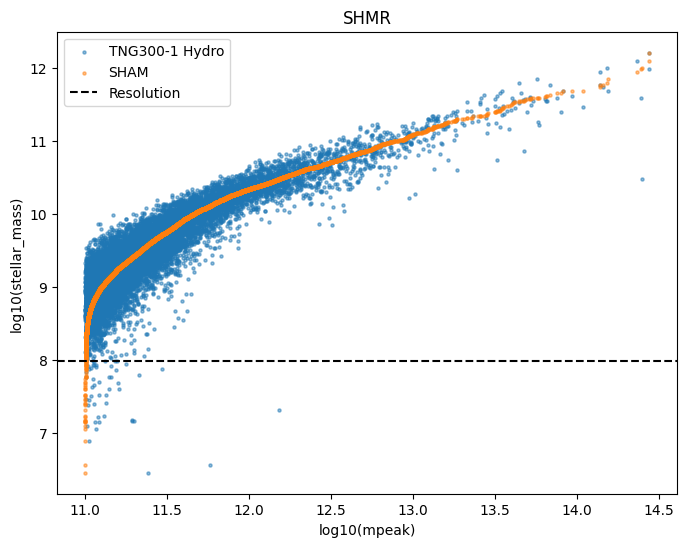

In [7]:
# SHMR
plt.figure(figsize=(8, 6))
plt.scatter(
    np.log10(hydro_high["mpeak"].data),
    np.log10(hydro_high["stellar_mass"].data),
    s=5,
    alpha=0.5,
    label="TNG300-1 Hydro",
)
plt.scatter(
    np.log10(hydro_high["mpeak"].data),
    logmstar_sham_high,
    s=5,
    alpha=0.5,
    label="SHAM",
)
plt.xlabel("log10(mpeak)")
plt.ylabel("log10(stellar_mass)")
plt.title("SHMR")
plt.axhline(RESOLUTION_CUT, c="k", ls="--", label="Resolution")

plt.legend()

# objects below resolution cut that make into SHMR (not sample, lower mpeak cut not applied)
# TODO: actually need to look
# print(f"Objects below resolution cut: {}")

In [8]:
x1 = np.log10(hydro_raw["stellar_mass"])
x2 = np.log10(hydro_raw["mpeak"])  # resolution

# NOTE: no cut on x2 high, only cut on x2 for low resolution
star_mask = (x1 > 9.5) & (x1 < 10.2) & (x2 > 11)
hydro_mstar_cut = hydro_raw[star_mask]
len(hydro_mstar_cut)

4050

In [9]:
# get sham stellar mass bin predicted catalog
sham_mask = (logmstar_sham_high > 9.5) & (logmstar_sham_high < 10.2)
hydro_sham = hydro_high[sham_mask]
len(hydro_sham)


4050

In [71]:
# get deviations from SHMR for each catalog, first on mpeak mass bin
log_mpeak = np.log10(hydro_raw["mpeak"])
log_mstar = np.log10(hydro_raw["stellar_mass"])
mask1 = log_mpeak > 11
mask2 = log_mpeak[mask1] < 12
star_dev = log_mstar[mask1][mask2] - logmstar_sham_high[mask2]
hydro_mpeak["shmr_dev"] = star_dev
star_dev.shape

(11310,)

In [ ]:
# now on stellar mass bin, does not have high mpeak cut!
log_mstar_high = np.log10(hydro_high["stellar_mass"])
mask = (log_mstar_high > 9.5) & (log_mstar_high < 10.2)
star_dev = log_mstar_high[mask] - logmstar_sham_high[mask]
hydro_mstar_cut["shmr_dev"] = star_dev
star_dev.shape

(4050,)

In [86]:
# finally on sham bin
log_mstar_high = np.log10(hydro_high["stellar_mass"])
star_dev = log_mstar_high[sham_mask] - logmstar_sham_high[sham_mask]
hydro_sham["shmr_dev"] = star_dev

(array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   1.,   4.,   1.,   9.,  13.,  31.,  80., 162.,
        305., 454., 590., 698., 537., 488., 314., 171.,  86.,  51.,  26.,
         12.,   5.,   4.,   6.,   1.,   0.,   0.,   0.,   1.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.]),
 array([-2.  , -1.92, -1.84, -1.76, -1.68, -1.6 , -1.52, -1.44, -1.36,
        -1.28, -1.2 , -1.12, -1.04, -0.96, -0.88, -0.8 , -0.72, -0.64,
        -0.56, -0.48, -0.4 , -0.32, -0.24, -0.16, -0.08,  0.  ,  0.08,
         0.16,  0.24,  0.32,  0.4 ,  0.48,  0.56,  0.64,  0.72,  0.8 ,
         0.88,  0.96,  1.04,  1.12,  1.2 ,  1.28,  1.36,  1.44,  1.52,
         1.6 ,  1.68,  1.76,  1.84,  1.92,  2.  ]),
 [<matplotlib.patches.Polygon at 0x11d307ed0>])

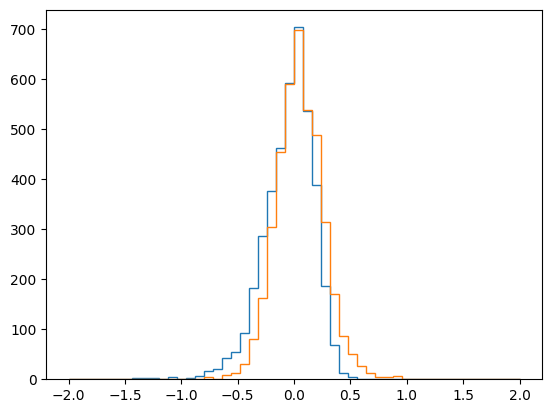

In [89]:
bins = np.linspace(-2.0, 2.0, 51)

plt.hist(hydro_sham["shmr_dev"], bins=bins, histtype="step")
plt.hist(hydro_mstar_cut["shmr_dev"], bins=bins, histtype="step")

# Heatmaps

In [93]:
def get_spearman_cov(cat, ns, scales, cat_names: list[str]):
    # lets create a spearman correlation matrix for all the following parameters
    a_n = get_an_from_mpeak_mah(cat["mpeak_mah"], scales=scales, ns=ns)

    mah_names = [f"a_1/{1 / n:.2g}" for n in ns]
    names = mah_names + cat_names

    param_values = np.concatenate(
        [cat[name].data.reshape(-1, 1) for name in cat_names], axis=-1
    )
    data = np.concatenate([a_n, param_values], axis=-1)
    n_params = len(names)

    # now compute spearman correlation between all of these parameters
    cov = np.zeros((n_params, n_params)) * np.nan
    for ii in range(n_params):
        for jj in range(n_params):
            cov[ii, jj] = spearmanr(data[:, ii], data[:, jj]).statistic

    return cov, names

In [98]:
_ns = np.linspace(0, 1, 21)[1:-1]
cat_names = ["mpeak", "stellar_mass", "vpeak", "shmr_dev", "color"]

cov_mpeak, names = get_spearman_cov(
    hydro_mpeak,
    ns=_ns,
    scales=scales,
    cat_names=cat_names,
)

cov_mstar, _ = get_spearman_cov(
    hydro_mstar_cut,
    ns=_ns,
    scales=scales,
    cat_names=cat_names,
)

cov_sham, _ = get_spearman_cov(
    hydro_sham,
    ns=_ns,
    scales=scales,
    cat_names=cat_names,
)

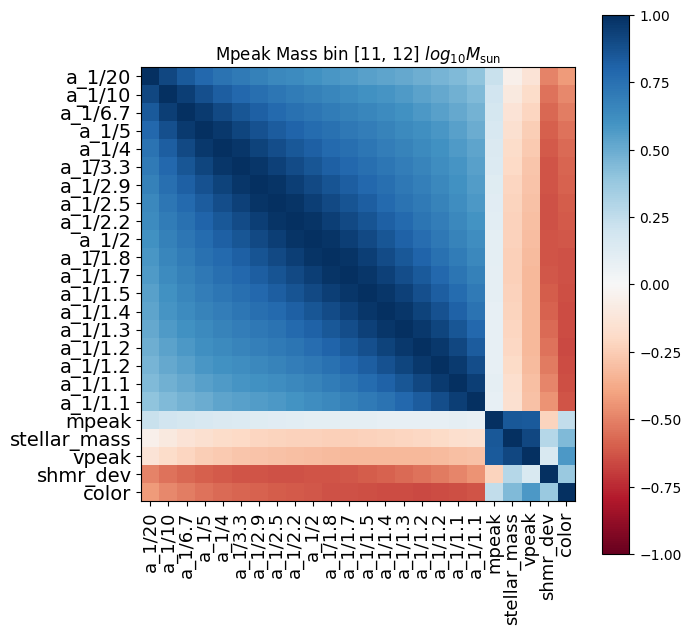

In [107]:
plt.figure(figsize=(7, 7))

ticks = np.arange(0, len(names), 1)

plt.imshow(cov_mpeak, cmap="RdBu", vmin=-1.0, vmax=1.0)
plt.xticks(ticks, labels=names)
plt.yticks(ticks, labels=names)

plt.xticks(fontsize=13, rotation=90)
plt.yticks(fontsize=14, rotation=0)

plt.title(r"Mpeak Mass bin [11, 12] $log_{10} M_{\rm sun}$")
plt.colorbar()

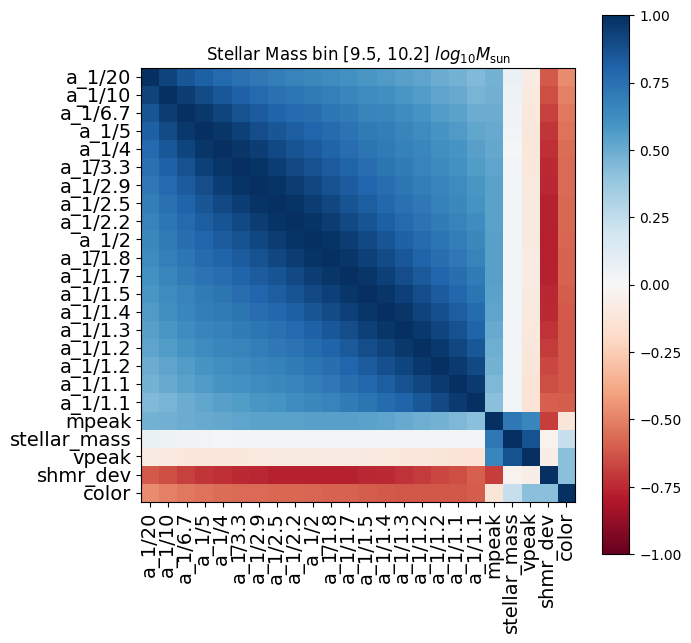

In [101]:
plt.figure(figsize=(7, 7))

ticks = np.arange(0, len(names), 1)

plt.imshow(cov_mstar, cmap="RdBu", vmin=-1.0, vmax=1.0)
plt.xticks(ticks, labels=names)
plt.yticks(ticks, labels=names)

plt.xticks(fontsize=14, rotation=90)
plt.yticks(fontsize=14, rotation=0)

plt.title(r"Stellar Mass bin [9.5, 10.2] $log_{10} M_{\rm sun}$")
plt.colorbar()

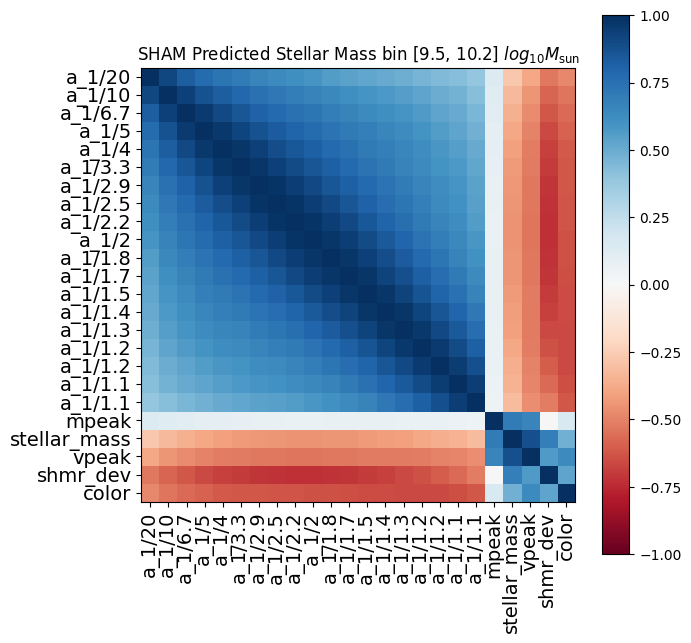

In [109]:
plt.figure(figsize=(7, 7))

ticks = np.arange(0, len(names), 1)

plt.imshow(cov_sham, cmap="RdBu", vmin=-1.0, vmax=1.0)
plt.xticks(ticks, labels=names)
plt.yticks(ticks, labels=names)

plt.xticks(fontsize=14, rotation=90)
plt.yticks(fontsize=14, rotation=0)

plt.title(r"SHAM Predicted Stellar Mass bin [9.5, 10.2] $log_{10} M_{\rm sun}$")
plt.colorbar()

(0.0, 0.8)

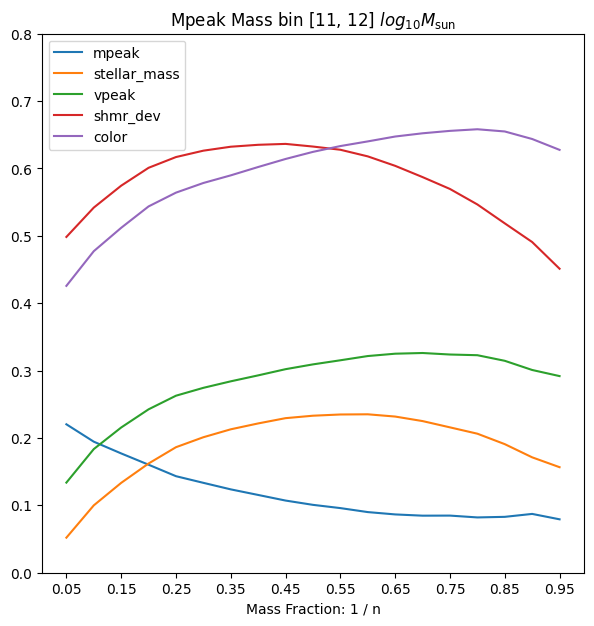

In [138]:
# now create curves for each MAH
plt.figure(figsize=(7, 7))
for name in cat_names:
    idx = names.index(name)
    corr_curve = cov_mpeak[: len(_ns), idx]
    plt.plot(_ns, np.absolute(corr_curve), label=name)
plt.legend()
plt.title(r"Mpeak Mass bin [11, 12] $log_{10} M_{\rm sun}$")
plt.xticks(_ns[::2])
plt.xlabel("Mass Fraction: 1 / n")
plt.ylim(0, 0.8)

(0.0, 0.8)

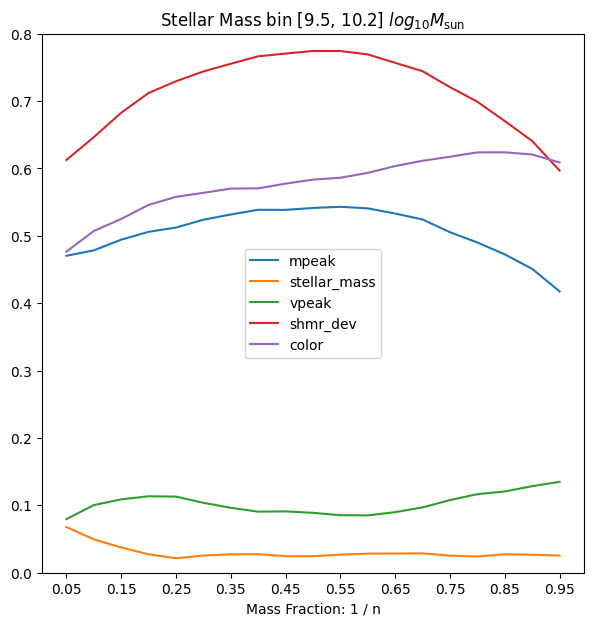

In [139]:
# now create curves for each MAH
plt.figure(figsize=(7, 7))
for name in cat_names:
    idx = names.index(name)
    corr_curve = cov_mstar[: len(_ns), idx]
    plt.plot(_ns, np.absolute(corr_curve), label=name)
plt.legend()
plt.title(r"Stellar Mass bin [9.5, 10.2] $log_{10} M_{\rm sun}$")
plt.xticks(_ns[::2])
plt.xlabel("Mass Fraction: 1 / n")
plt.ylim(0, 0.8)

(0.0, 0.8)

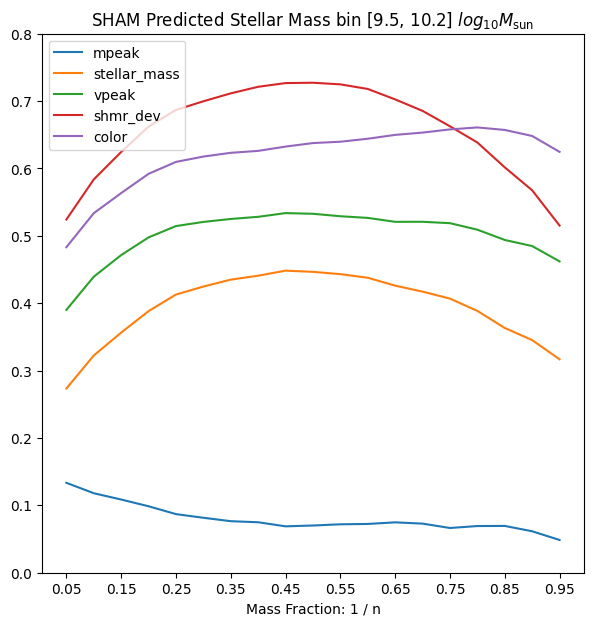

In [140]:
# now create curves for each MAH
plt.figure(figsize=(7, 7))
for name in cat_names:
    idx = names.index(name)
    corr_curve = cov_sham[: len(_ns), idx]
    plt.plot(_ns, np.absolute(corr_curve), label=name)
plt.legend()
plt.title(r"SHAM Predicted Stellar Mass bin [9.5, 10.2] $log_{10} M_{\rm sun}$")
plt.xticks(_ns[::2])
plt.xlabel("Mass Fraction: 1 / n")
plt.ylim(0, 0.8)